# Experiment: Long Random Sequence Spatial Annotation

Create one final spatial_annotation.json for each of the five usable random-trajectory sessions. This notebook deliberately does not import or reuse geometry from Notebook 09.

**Coordinate convention:** paper center is (0, 0) cm, x points right and y points down in the calibrated single-frame desk view. The canonical paper is 26.5 × 26.5 cm.


## Annotation contract

For each session:

1. Choose one contiguous inclusive raw-CSV usable range. The default spans all flag-2 readings; adjust it only to remove unusable start/end material.
2. Move **Reference row** until both panels show a sharp, unobstructed frame. The tool calibrates this frame from the desk Tag 6 pose measured at that row, so camera motion during a session is supported.
3. Click the four paper corners in cyclic order: top-left, top-right, bottom-right, bottom-left.
4. For every present odor strip, click its four **outer-edge** corners in cyclic order.
5. Use **Undo last click** to remove the most recently clicked point across all features, or **Reset current** to clear the selected feature.
6. Inspect the matching raw-frame reprojection on the right, then click **Save final JSON**. Saving is the final action and overwrites an existing annotation for that session.

If the requested reference row has no qualified Tag 6 pose, the tool uses the nearest qualified row and reports the actual row under the controls.


In [1]:
import importlib.util
import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import display


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (
            candidate / "analysis" / "spatial_sequence"
        ).is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the repository root from the kernel working directory: "
        f"{start}"
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
repository_path = str(REPOSITORY_ROOT)
if repository_path not in sys.path:
    sys.path.insert(0, repository_path)
print(f"Repository root: {REPOSITORY_ROOT}")

if importlib.util.find_spec("ipympl") is None:
    print("ipympl is not installed in this kernel; install the package requirements before interactive annotation.")
else:
    get_ipython().run_line_magic("matplotlib", "widget")

from analysis.spatial_sequence.annotation import SpatialAnnotationTool, annotation_status_table
from analysis.spatial_sequence.core import discover_sessions

sessions = discover_sessions()
print(f"Discovered {len(sessions)} usable sessions.")

Repository root: /nfs/turbo/coe-ahowens-nobackup/xclu/realsense-apriltag


Discovered 5 usable sessions.


## Current status

This table is safe to run before any annotation exists. A valid row means the JSON passes schema and geometry validation.

In [2]:
status = annotation_status_table(sessions)
display(status)

,session_id,trial_id,layout,annotation,usable_start_row,usable_end_row,paper_fit_rms_cm
0,20260730_152754,2026-07-30_mint_only_horizontal_random_10min_r...,mint-only horizontal,valid,58,705,0.162833
1,20260730_153631,2026-07-30_caret_mint_left_lavender_right_rand...,caret mint-left lavender-right,valid,22,736,0.201972
2,20260730_154848,2026-07-30_caret_lavender_left_mint_right_rand...,caret lavender-left mint-right,valid,54,758,0.171148
3,20260730_161358,2026-07-30_lavender_only_horizontal_random_10m...,lavender-only horizontal,valid,47,828,0.159808
4,20260730_163355,2026-07-30_inverted_caret_lavender_left_mint_r...,inverted caret lavender-left mint-right,valid,26,1113,0.316266


## Interactive annotation

The left panel is a calibrated view made from one selected raw frame and is the only click target. The right panel shows that same raw frame with the clicked desk geometry reprojected for QC. Moving **Reference row** recalculates both panels using the Tag 6 pose at the selected time. Complete and save all five sessions using the session dropdown.


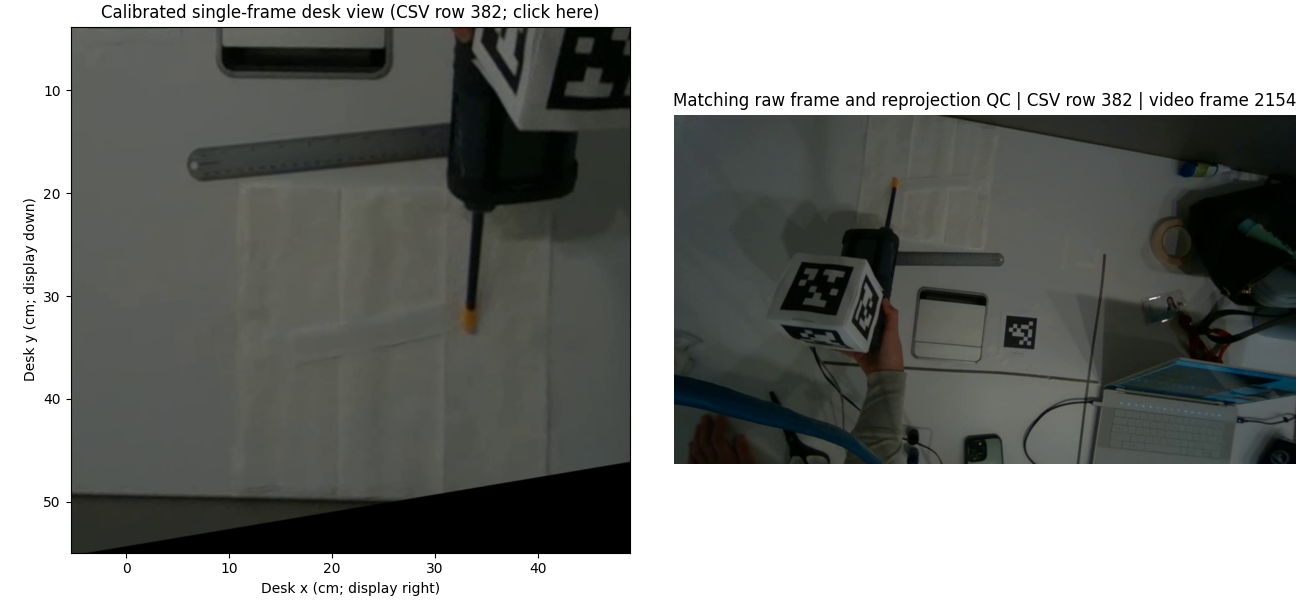

In [3]:
tool = SpatialAnnotationTool(sessions)
display(tool.widget)

## Final validation

Run this after saving all five sessions. Training is ready only when every row is `valid`.

In [4]:
final_status = annotation_status_table(sessions)
display(final_status)
if (final_status["annotation"] == "valid").all():
    print("All five spatial annotations are valid. Stage-two training can begin.")
else:
    print("Annotation is incomplete; finish every non-valid session before training.")

,session_id,trial_id,layout,annotation,usable_start_row,usable_end_row,paper_fit_rms_cm
0,20260730_152754,2026-07-30_mint_only_horizontal_random_10min_r...,mint-only horizontal,valid,58,705,0.162833
1,20260730_153631,2026-07-30_caret_mint_left_lavender_right_rand...,caret mint-left lavender-right,valid,22,736,0.201972
2,20260730_154848,2026-07-30_caret_lavender_left_mint_right_rand...,caret lavender-left mint-right,valid,54,758,0.171148
3,20260730_161358,2026-07-30_lavender_only_horizontal_random_10m...,lavender-only horizontal,valid,47,828,0.159808
4,20260730_163355,2026-07-30_inverted_caret_lavender_left_mint_r...,inverted caret lavender-left mint-right,valid,26,1113,0.316266


All five spatial annotations are valid. Stage-two training can begin.


## Notes

- No temporal median is used; the annotation view is one calibrated frame chosen with **Reference row**.
- Each reference view and its raw-frame overlay use the desk Tag 6 pose from the same CSV row. This preserves a stable desk coordinate system if the camera moves while the desk and tag remain fixed.
- When Tag 6 is unavailable at the requested row, the nearest row with a finite qualified Tag 6 pose is used and displayed.
- Raw video frames are selected from synchronized pose elapsed time and the recorded MP4 timeline.
- Model inputs remain strictly the 32 raw flag-2 smell channels. Annotation geometry is used only to construct labels and evaluation overlays.
- Call tool.close() when finished to release the video handle.
